# Performance of Foster's CIR solver vs the Drift-implicit Euler scheme applied to the CIR process

We compare the performance of the two solvers on two examples of the CIR process, an easier one and a stiffer one. We also compare adaptive step size control with a fixed step size.

## Summary of results
Medium-volatility CIR (a=1, b=1, sigma=1.5):
- HOStS non-adaptive: 0.7824
- HOStS adaptive: 1.8225
- DriftImplicitEuler non-adaptive: 0.8618
- DriftImplicitEuler adaptive: 1.0269

High-volatility CIR (a=1, b=1, sigma=2.2):
- HOStS non-adaptive: 0.3944
- HOStS adaptive: 0.8092
- DriftImplicitEuler non-adaptive: 0.4642
- DriftImplicitEuler adaptive: 0.8618

In [2]:
from typing import Optional


%env JAX_PLATFORM_NAME=cuda

from test.helpers import get_cir, simple_sde_order

import jax.numpy as jnp
import jax.random as jr
import pandas as pd
from diffrax import (
    diffeqsolve,
    DriftImplicitEulerCIR as DIE,
    HOStS,
    SaveAt,
)
from diffrax._step_size_controller.cir_adaptive import CIRController
from drawing_and_evaluating import (
    constant_step_strong_order,
    draw_order_multiple,
    plot_sol_general,
)
from jax import config


config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", "{:.3}".format)


def cir_strong_order(keys, sde, solver, levels, bm_tol=None):
    def get_controller(level):
        return CIRController(
            ctol=2**-level,
            dtmin=2**-14,
            dtmax=1.0,
        )

    if bm_tol is None:
        bm_tol = 2**-14
    return simple_sde_order(
        keys, sde, solver, solver, levels, get_controller, SaveAt(t1=True), bm_tol
    )


def print_stats(
    steps_errs_ord: tuple,
    _tols: Optional[jnp.ndarray],
):
    num_steps, errs, order = steps_errs_ord
    column_names = ["num_steps", "errs"]
    columns = [num_steps, errs]
    if _tols is not None:
        tols_pow_hs = jnp.power(_tols, 2 / 3) * num_steps
        columns.extend([_tols, _tols / errs, _tols * num_steps, tols_pow_hs])
        column_names.extend(["tols", "tols/errs", "tols/hs", "tols^(2/3)/hs"])
    _table = jnp.stack(columns, axis=1)
    # Now use pandas to nicely print the table with the headers
    table = pd.DataFrame(_table, columns=column_names)
    print(table)


dtype = jnp.float64
num_samples = 1000
bm_key = jr.PRNGKey(2)
keys = jr.split(jr.PRNGKey(5678), num=num_samples)


def ctols(levels):
    return jnp.power(2.0, -jnp.arange(levels[0], levels[1] + 1, dtype=dtype))


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)


t0, t1 = 0.0, 16.0
t_short = 4.0
t_long = 32.0
saveat = SaveAt(steps=True)
dt0 = 1 / 8
levels_const = (3, 12)
levels_adap = (0, 12)
levels_hard_adap = (1, 10)


args = (1.0, 1.0, 1.5)
print(f"tilde_b: {args[1] - (args[2]**2)/(4.0 * args[0])}")
cir = get_cir(t0, t1, args, dtype=dtype)
terms_cir = cir.get_terms(cir.get_bm(bm_key, levy_area="space-time", tol=2**-12))
cir_short = get_cir(t0, t_short, args, dtype=dtype)
args_hard = (1.0, 1.0, 2.2)
cir_hard = get_cir(t0, t_short, args_hard, dtype=dtype)
terms_cir_hard = cir_hard.get_terms(
    cir_hard.get_bm(bm_key, levy_area="space-time", tol=2**-14)
)
print(f"tilde_b_hard: {args_hard[1] - (args_hard[2]**2)/(4.0 * args_hard[0])}")

env: JAX_PLATFORM_NAME=cuda
tilde_b: 0.4375
tilde_b_hard: -0.2100000000000002


## Easy problem with medium volatility and positive tilde_b
a=1, b=1, sigma=1.5

In [3]:
print("Easy HOStS non-adaptive")
hosts_easy_const = constant_step_strong_order(keys, cir_short, HOStS(), levels_const)
print_stats(hosts_easy_const, None)

print("Easy HOStS with CIRController")
hosts_easy_adap = cir_strong_order(keys, cir_short, HOStS(), levels_adap)
print_stats(hosts_easy_adap, ctols(levels_adap))

print("Easy DIE non-adaptive")
die_easy_const = constant_step_strong_order(keys, cir_short, DIE(), levels_const)
print_stats(die_easy_const, None)

print("Easy DIE with CIRController")
die_easy_adap = cir_strong_order(keys, cir_short, DIE(), levels_adap)
print_stats(die_easy_adap, ctols(levels_adap))

Easy HOStS non-adaptive
   num_steps     errs
0        8.0    0.143
1       16.0   0.0797
2       32.0   0.0461
3       64.0   0.0259
4   1.28e+02   0.0139
5   2.56e+02  0.00839
6   5.12e+02  0.00454
7   1.02e+03   0.0028
8   2.05e+03  0.00161
9    4.1e+03 0.000959
Easy HOStS with CIRController
    num_steps     errs     tols  tols/errs  tols/hs  tols^(2/3)/hs
0        11.1   0.0925      1.0       10.8     11.1           11.1
1        19.7   0.0353      0.5       14.2     9.84           12.4
2        34.6   0.0164     0.25       15.2     8.64           13.7
3        58.3  0.00501    0.125       25.0     7.28           14.6
4        94.3  0.00217   0.0625       28.8     5.89           14.8
5    1.51e+02  0.00102   0.0312       30.7      4.7           14.9
6    2.33e+02 0.000426   0.0156       36.7     3.65           14.6
7    3.52e+02 0.000202  0.00781       38.6     2.75           13.9
8    5.26e+02 0.000109  0.00391       35.7     2.06           13.1
9    7.92e+02 7.28e-05  0.00195   

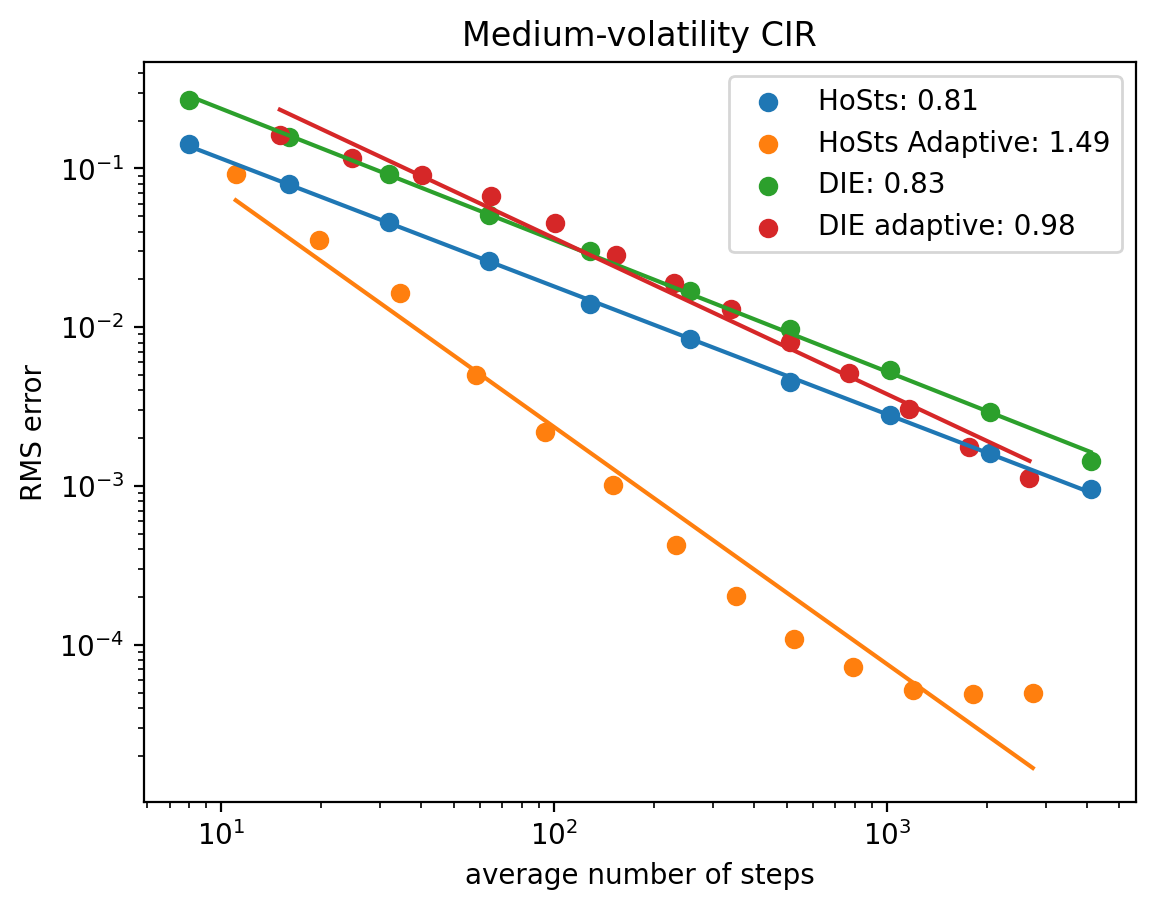

In [4]:
draw_order_multiple(
    [hosts_easy_const, hosts_easy_adap, die_easy_const, die_easy_adap],
    ["HoSts", "HoSts Adaptive", "DIE", "DIE adaptive"],
    "Medium-volatility CIR",
)

## Hard problem with high volatility and negative tilde_b
a=1, b=1, sigma=2.2

In [5]:
print("Hard HOStS non-adaptive")
hosts_hard_const = constant_step_strong_order(keys, cir_hard, HOStS(), levels_const)
print_stats(hosts_hard_const, None)

print("Hard HOStS with CIRController")
hosts_hard_adap = cir_strong_order(keys, cir_hard, HOStS(), levels_hard_adap)
print_stats(hosts_hard_adap, ctols(levels_hard_adap))

print("Hard DIE non-adaptive")
die_hard_const = constant_step_strong_order(keys, cir_hard, DIE(), levels_const)
print_stats(die_hard_const, None)

print("Hard DIE with CIRController")
die_hard_adap = cir_strong_order(keys, cir_hard, DIE(), levels_hard_adap)
print_stats(die_hard_adap, ctols(levels_hard_adap))

Hard HOStS non-adaptive
   num_steps   errs
0        8.0  0.919
1       16.0  0.642
2       32.0  0.435
3       64.0  0.334
4   1.28e+02  0.254
5   2.56e+02  0.187
6   5.12e+02  0.154
7   1.02e+03  0.107
8   2.05e+03 0.0877
9    4.1e+03 0.0657
Hard HOStS with CIRController
   num_steps   errs     tols  tols/errs  tols/hs  tols^(2/3)/hs
0   3.42e+02  0.351      0.5       1.42 1.71e+02       2.15e+02
1   3.04e+02  0.206     0.25       1.22     76.0       1.21e+02
2   3.78e+02  0.128    0.125      0.976     47.2           94.4
3   6.43e+02 0.0808   0.0625      0.773     40.2       1.01e+02
4   1.16e+03 0.0417   0.0312      0.749     36.3       1.15e+02
5   1.93e+03 0.0243   0.0156      0.644     30.1       1.21e+02
6    2.7e+03 0.0157  0.00781      0.497     21.1       1.06e+02
7   3.37e+03 0.0135  0.00391       0.29     13.2           83.7
8   4.17e+03 0.0135  0.00195      0.145     8.14           65.1
9   5.24e+03 0.0128 0.000977     0.0764     5.12           51.6
Hard DIE non-adaptive


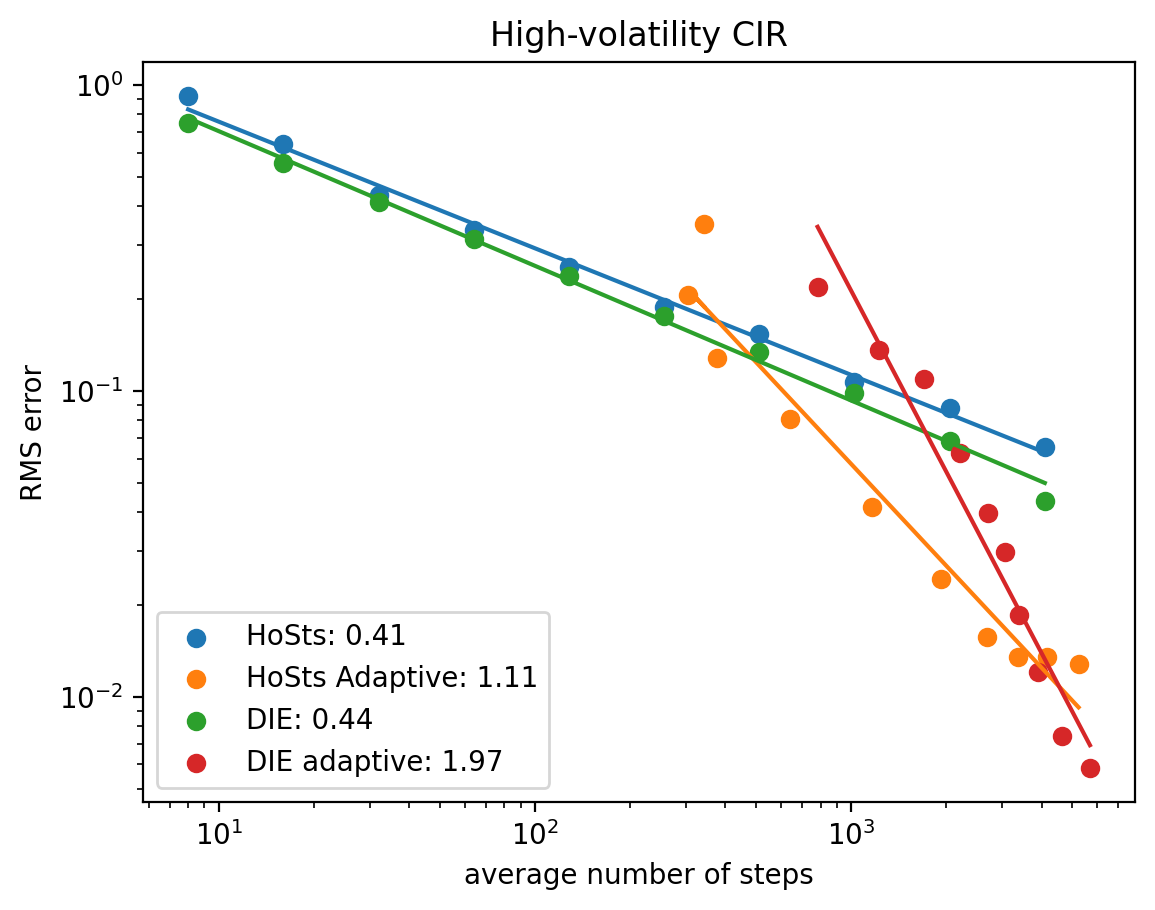

In [6]:
draw_order_multiple(
    [hosts_hard_const, hosts_hard_adap, die_hard_const, die_hard_adap],
    ["HoSts", "HoSts Adaptive", "DIE", "DIE adaptive"],
    "High-volatility CIR",
)

In [ ]:
print("DIE non-adaptive sample path")
solDIE = diffeqsolve(terms_cir, DIE(), t0, t1, dt0, cir.y0, cir.args, saveat=saveat)
plot_sol_general(solDIE)

print("DIE adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solDIE_pid = diffeqsolve(
    terms_cir,
    DIE(),
    t0,
    t1,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solDIE_pid)
print(f'num steps: {solDIE_pid.stats["num_accepted_steps"]}')

In [ ]:
print("HOStS (hard) adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solCIR_cont = diffeqsolve(
    terms_cir_hard,
    HOStS(),
    t0,
    t_short,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solCIR_cont)
print(f'num steps: {solCIR_cont.stats["num_accepted_steps"]}')

print("HOStS non-adaptive sample path")
solCIR = diffeqsolve(
    terms_cir, HOStS(1.0), t0, t1, dt0, cir.y0, cir.args, saveat=saveat
)
plot_sol_general(solCIR)

print("HOStS adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solCIR_cont = diffeqsolve(
    terms_cir,
    HOStS(1.0),
    t0,
    t1,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solCIR_cont)
print(f'num steps: {solCIR_cont.stats["num_accepted_steps"]}')

Easy Foster with CIRController


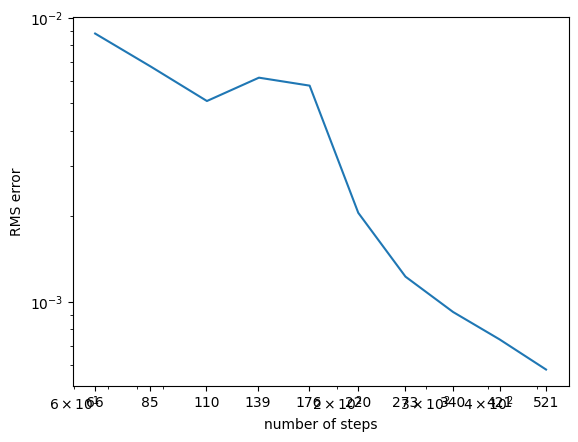

Order of convergence: 1.435, intercept: -0.426
       hs  num_steps     errs     tols  tols/errs  tols/hs  tols^(2/3)/hs
0  0.0605       66.1  0.00879 0.000122     0.0139  0.00202         0.0406
1  0.0469       85.4  0.00671  6.1e-05    0.00909   0.0013         0.0331
2  0.0363    1.1e+02  0.00509 3.05e-05      0.006 0.000841         0.0269
3  0.0286    1.4e+02  0.00615 1.53e-05    0.00248 0.000534         0.0215
4  0.0227   1.76e+02  0.00576 7.63e-06    0.00132 0.000337         0.0171
5  0.0181    2.2e+02  0.00206 3.81e-06    0.00185  0.00021         0.0135
6  0.0146   2.74e+02  0.00123 1.91e-06    0.00156 0.000131         0.0105
7  0.0117    3.4e+02 0.000921 9.54e-07    0.00104 8.12e-05        0.00825
8  0.0095   4.21e+02 0.000738 4.77e-07   0.000646 5.02e-05        0.00642
9 0.00768   5.21e+02 0.000578 2.38e-07   0.000413 3.11e-05        0.00501


In [5]:
from diffrax._step_size_controller.sde_adaptive import SDEController


# Adaptive convergence with the non-adaptive solution as reference
# Showing that indeed we converge to the correct solution
print("Easy HOStS with CIRController")
_, fos_adap_errs2, fos_adap_steps2, _ = cir_strong_order(
    keys,
    cir_short,
    HOStS(half_stepping=True),
    2**-24,
    ctols(23),
    _controller=SDEController,
)
# draw_adaptive_order(fos_adap_errs2, fos_adap_steps2)
print_stats(fos_adap_errs2, 4.0, ctols(23), num_steps=fos_adap_steps2)
#
# print("Hard-CIR HOStS with CIRController")
# _, fos_hard_adap_errs2, fos_hard_adap_steps2, _ = cir_strong_order(
#     keys, cir_hard, HOStS(half_stepping=True),
#     2**-12, ctols(11), _controller=SDEController
# )
# draw_adaptive_order(fos_hard_adap_errs2, fos_hard_adap_steps2)
# print_stats(fos_hard_adap_errs2, 4.0, ctols(11), num_steps=fos_hard_adap_steps2)